# **Modeling Inflammatory Bowel Disease Progression with Group Lasso for logistic regression**
==================================

# I. Data Preparation
To prepare data for Group-Lasso logistic regression modeling of Inflammatory Bowel Disease (IBD) flares based on MyIBDcoach variables, follow these steps:

1. **Define Variable Groups**: Identify and categorize variables into groups such as baseline characteristics, psychosocial factors, lifestyle choices, medication usage, and tool usage.

2. **Import Data**: Load the necessary datasets from Excel files using `read_excel()`, ensuring to define column names.

3. **Prepare BaseLine Data**: Extract baseline-related information.

4. **Prepare Medication Data**: Extract medication-related information, creating a binary indicator for whether each user is taking specific medications, and Reshape Medication Data into the correct format, using `pivot_wider()`, allowing each medication to become a separate column with binary indicators.

5.  **Prepare psychosocial Data**:  Extract psychosocial-related information,

6.  **Prepare lifestyle Data**:  Extract lifestyle-related information,

7.  **Prepare tool usage Data**:  Extract tool-usage-related information,

8.  **Prepare Flare Data**: Extract the dependent variable.

9.  **Join all Datasets**: Merge all main datasets based on the `UserName` variable to create a comprehensive dataset that includes all relevant predictors for modeling IBD flare.

This structured approach ensures that all necessary variables are included and properly formatted for effective analysis using Group-Lasso logistic regression, facilitating insights into factors influencing IBD flare events.

In [1]:
# Load Required Libraries
# -----------------------
library(knitr)
library(labelled)     # For handling variable labels
knitr::opts_chunk$set(erro= F, warning= F, message=F, fig.width = 8, collapse = TRUE)
library(readxl) # import xlsx data
library(gglasso) # load gglasso library
library(tidyverse)
library(pROC)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Type 'citation("pROC")' for a citation.


Attaching package: ‘pROC’


The following objects are masked from ‘package:stats’:

    cov, smooth, var




### Import Data

In [2]:
# Import data from Excel file
## 1. Import baseline & psychosocial data
### Define your desired column names
desired_col_names <- c('UserName','IBDZL','Center','NumberOfMeasurements',
                       'NumberOfMeasurementsWithCalproWithinRange',
                       'NumberofMeasurementsMeetingCalpro<150Pain>2','PercCriteria1',
                       'PercCriteria2',
                       'NumberofMeasurementsMeetingCalpro<150Pain<3','PercCriteria',
                       'GroupsCalpro<150Pain>2','GroupNewReversed','Gender','DateofBirth',
                       'AgeAtCohortEntry','DiseaseEntity','DiagDateFinal','AgeatDiag',
                       'DiseaseDurationAtCohortEntry','DiseaseDurationCategory','Montreal_A_diag',
                       'Montreal_L_diag_final','Montreal_B_diag_final','Montreal_P_diag_final',
                       'Montreal_P_ever_manualfinal','Montreal_U_diag_final','Montreal_U_ever_final',
                       'Montreal_E_diag_Final','Montreal_E_ever_final',
                       'IBDsurgeryHistory_manualfinal','IBDsurgery_resection_manualfinal',
                       'CCI_adjusted','BMI_baseline','BMI_category',
                       'CurrentStoma','Stoma_history','Smoking_final','Family_IBD_final',
                       'MIAH_pain_median','MIAH_pain_firstvalue','MIAH_pain_mean',
                       'Stress_median','Stress_firstvalue','Stress_mean',
                       'Depression_median_1','Depression_firstvalue_1','Depression_mean_1',
                       'Depression_median_2','Depression_firstvalue_2','Depression_mean_2',
                       'Anxious_median_1','Anxious_firstvalue_1','Anxious_mean_1',
                       'Anxious_median_2','Anxious_firstvalue_2','Anxious_mean_2',
                       'Fatigue_median_1','Fatigue_firstvalue_1','Fatigue_mean_1',
                       'Fatigue_median_2','Fatigue_firstvalue_2','Fatigue_mean_2',
                       'LifeEvents_incase')

## 1. Import data using the defined col names
data <- read_excel("/kaggle/input/database/data.xlsx", sheet = 1,col_names = desired_col_names,skip = 1)#Baseline

## 2. Import Medication Data
dataMed <- read_excel("/kaggle/input/database/PRIQ_Masterfile_Medication_MUMCZDL_0812proj.xlsx", sheet = 1)#Medication

## 3. Import lifestyle Data
dataLifeStyle <- read_excel("/kaggle/input/database/Physical Exercise.xlsx", sheet = 1)#lifestyle

print(paste0('Data source import complete'))

[1] "Data source import complete"


In [3]:
table(data$GroupNewReversed)


  0   1 
231 198 

## I.2 Prepare BaseLine &  psychosocial data

Let's start with the baseline data, here are the explanatory variables in the Baseline:





| Label                                   | Variable Name                                         | Measurement Scale | # of Levels | Categories                               |
|-----------------------------------------|------------------------------------------------------|-------------------|-------------|------------------------------------------|
| Gender                                  | Gender                                               | Nominal           | 2           | Female, Male                             |
| AgeAtCohortEntry                       | Age at baseline (years)                             | Interval          |             |                                          |
| DiseaseEntity                           | Phenotype                                           | Nominal           | 2           | CD, UC                                   |
| DiseaseDurationAtCohortEntry           | Disease duration                                    | Interval          |             |                                          |
| DiseaseDurationCategory                 | Disease duration                                    | Nominal           | 2           |                                          |
| AgeatDiag                               | Age at diagnosis                                    | Ratio             |             |                                          |
| Montreal_A_diag                         | Montreal at diagnosis: Age                          | Nominal           | 3           | <16, 16-40, >40                          |
| Montreal_L_Diag                         | Montreal at diagnosis: Disease location (CD)       | Nominal           | 3           | ileal, colonic, ileocolonic             |
| Montreal_B_Diag                         | Montreal at diagnosis: Disease behavior (CD)       | Nominal           | 3           | inflammatory, stricturing, penetrating   |
| Montreal_P_diag_final                   | Montreal at diagnosis: Perianal disease (CD)      | Nominal           | 3           | ileal, colonic, ileocolonic             |
| Montreal_U_diag_final                   | Montreal at diagnosis: Upper GI disease (CD)      | Nominal           | 2           | No, Yes                                  |
| Montreal_E_diag_Final                   | Montreal at diagnosis: Disease extent (UC)         | Nominal           | 3           | proctitis, left-sided colitis, extensive/pancolitis |
| Montreal_P_ever_manualfinal             | Montreal: Perianal disease maximum (CD)            | Nominal           | 2           | No, Yes                                  |
| Montreal_U_ever_final                   | Montreal: Upper GI disease maximum (CD)            | Nominal           | 2           | No, Yes                                  |
| Montreal_E_ever_final                   | Montreal: Disease extent UC maximum                 | Nominal           | 3           | proctitis, left-sided colitis, extensive/pancolitis |
| IBDsurgeryHistory_manualfinal            | History of IBD surgery                              | Nominal           | 2           | No, Yes                                  |
| IBDsurgery_resection_manualfinal        | IBD surgery resection                               | Nominal           | 2           | No, Yes                                  |
| Family_IBD_final                        | Family history IB                                   | Nominal           | 2           | No, Yes                                  |
| Smoking_final                           | Current smoking at baseline                         | Nominal           | 2           | No, Yes                                  |
| CurrentStoma                           | Current stoma at baseline                           | Nominal           | 2           | No, Yes                                  |
| Stoma_history                          | History of stoma at baseline                        | Nominal           | 2           | No, Yes                                  |
| BMI_baseline                           | BMI at baseline                                     | Ratio             |             |                                          |
| BMI_category                           | BMI category at baseline                            | Nominal           | 3           | 18.5-25.0, 25.0-30.0, ≥30.0            |
| CCI_adjusted                           |- Adjusted rate ratios for Crohn’s disease-related surgery. CCI   |- Nominal      |- 3         |- 0, 1-2, >2                              |

Medication at baseline 

In [4]:
data$MIAH_pain <-  data$MIAH_pain_mean  #data$MIAH_pain_median + data$MIAH_pain_firstvalue +
data$Stress <- data$Stress_mean # data$Stress_median + data$Stress_firstvalue + 
data$Depression1 <- data$Depression_mean_1 # data$Depression_median_1 + data$Depression_firstvalue_1 + 
data$Depression2 <- data$Depression_mean_2 # data$Depression_median_2 + data$Depression_firstvalue_2 + 
data$Anxious1 <- data$Anxious_mean_1# data$Anxious_median_1 + data$Anxious_firstvalue_1 + 
data$Anxious2 <- data$Anxious_mean_2 # data$Anxious_median_2 + data$Anxious_firstvalue_2 + 
data$Fatigue1 <- data$Fatigue_mean_1 # data$Fatigue_median_1 + data$Fatigue_firstvalue_1 + 
data$Fatigue2 <- data$Fatigue_mean_2 # data$Fatigue_median_2 + data$Fatigue_firstvalue_2 + 

In [5]:
data <- data %>%
  select(-c(2:11, 39:62,DateofBirth,DiagDateFinal))  # Drop first 11 variables: 'IBDZL''Center''NumberOfMeasurements''NumberOfMeasurementsWithCalproWithinRange''NumberofMeasurementsMeetingCalpro<150Pain>2''PercCriteria...7''PercCriteria...8''NumberofMeasurementsMeetingCalpro<150Pain<3''PercCriteria...10''GroupsCalpro<150Pain>2'

In [6]:
# Preparing data 
# Convert response variables to factor  
data$GroupNewReversed <- factor(data$GroupNewReversed, labels= c("no flares", "flares"))
data$Gender <- factor(data$Gender, labels= c("Female", "Male"))  
data$DiseaseEntity <- factor(data$DiseaseEntity, labels= c("CD", "UC"))
data$DiseaseDurationCategory <- factor(data$DiseaseDurationCategory)#, labels= 3 cats c())
data$IBDsurgeryHistory_manualfinal <- factor(data$IBDsurgeryHistory_manualfinal, labels= c("No", "Yes"))
data$IBDsurgery_resection_manualfinal <- factor(data$IBDsurgery_resection_manualfinal, labels= c("No", "Yes"))
data$CCI_adjusted <- factor(data$CCI_adjusted, labels= c("0", "1-2", ">2"))
data$BMI_category <- factor(data$BMI_category, labels= c("18.5-25.0", "25.0-30.0","≥30.0"))
data$CurrentStoma <- factor(data$CurrentStoma, labels= c("No", "Yes"))
data$Stoma_history <- factor(data$Stoma_history, labels= c("No", "Yes"))
data$Family_IBD_final <- factor(data$Family_IBD_final)#, labels=3 cats c())
data$Montreal_A_diag <- factor(data$Montreal_A_diag, labels= c("<16", "16-40",">40"))
data$Montreal_L_diag_final   <- factor(data$Montreal_L_diag_final, labels= c("ileal","colonic","ileocolonic","NA"))# "upper GI"
data$Montreal_B_diag_final  <- factor(data$Montreal_B_diag_final, labels= c("inflammatory","stricturing", "penetrating","NA"))
data$Montreal_P_diag_final   <- factor(data$Montreal_P_diag_final, labels= c("No", "Yes","NA"))
data$Montreal_P_ever_manualfinal  <- factor(data$Montreal_P_ever_manualfinal, labels= c("No", "Yes","NA"))
data$Montreal_U_diag_final  <- factor(data$Montreal_U_diag_final, labels= c("No", "Yes","NA"))
data$Montreal_U_ever_final  <- factor(data$Montreal_U_ever_final, labels= c("No", "Yes","NA"))
data$Montreal_E_diag_Final <- factor(data$Montreal_E_diag_Final, labels= c("proctitis", "left-sided colitis","extensive/pancolitis","NA"))
data$Montreal_E_ever_final <- factor(data$Montreal_E_ever_final, labels= c("proctitis", "left-sided colitis","extensive/pancolitis","NA"))

## I.3 Prepare Medicament data

In [7]:
dataMed <- dataMed %>% select(c(Username, Medicament))
dataMed$value <-  1  # Create a column with 1s indicating medication taken

# reshaping the data : Transform the data from long to wide format
wide_dataMed <- dataMed %>%
  pivot_wider(names_from = Medicament,
              values_from = value, values_fill = list(value = 0),
              values_fn = list(value = sum))%>%
  rename(UserName = Username)          # Rename the variable



# Convert MEDICATION columns to factors with labels No, Yes, and NA
wide_dataMed[c(-1)] <- wide_dataMed[c(-1)] %>%
  mutate(across(everything(), 
                 ~ factor(.,
                          levels= c(0,1, "NA"),  # Add "NA" as a level
                           labels = c("No", "Yes", "NA" ) ,
                         exclude = NULL)))  # Include NA as a level
wide_dataMed <- wide_dataMed %>%
  select(UserName,Adalimumab, `Budesonide`, `Geen medicatie`, Infliximab, 
         Mercaptopurine, Mesalazine, Prednison, Tioguanine,
         Ustekinumab, Vedolizumab)

## I.4 Prepare lifestyle Data

In [8]:
# Smoking Status
data$Smoking_final <- factor(data$Smoking_final, labels= c("Never", "Current","Former"))

# Reorder variables in dataLifeStyle, moving Smoking_final to the end
data <- data %>%
  select(-Smoking_final, everything(), Smoking_final)

# Life Events
data$LifeEvents_inCase  <- factor(data$LifeEvents_incase, labels= c("No", "Yes"))
data$LifeEvents_incase  <- NULL

# Physical Exercise
## Recode 'Physical Exercise' to factor with two levels
data$PhysicalExercise <- recode(dataLifeStyle$`Physical Exercise`,
                                            `0` = "none",   # 0 becomes "none"
                                            `1` = "none",  # 1 becomes "none"
                                            `2` = "none",  # 2 becomes "none"
                                            `3` = "none",  # 3 becomes "none"
                                            `4` = "none",  # 4 becomes "none"
                                            `5` = "very active")  # 5 becomes "very active"

## Convert to factor
data$PhysicalExercise <- as.factor(data$PhysicalExercise)



### I.5 Join-Datasets based on UserName

In [9]:
joined_data <- data %>%
  left_join(wide_dataMed, by = "UserName")  # Use inner_join to combine by UserName

#joined_data <- na.omit(joined_data)

In [10]:
# Set variable labels
joined_data <- joined_data %>%
  set_variable_labels(
     GroupNewReversed=  "Flares",
    BMI_category   = "BMI at baseline",        
CCI_adjusted =       	"CCI Adjusted",
CurrentStoma  =   "Current stoma at baseline",
DiseaseDurationCategory  =   "Disease duration",
DiseaseEntity  =   "Phenotype",
Family_IBD_final  =   "Family history IB",
Gender  =   "Gender",
IBDsurgeryHistory_manualfinal =   "History of IBD surgery",
IBDsurgery_resection_manualfinal =   "IBD surgery resection",
Montreal_A_diag =   "Montreal at diagnosis: Age",
Montreal_B_diag_final  =   "Montreal at diagnosis: Disease behavior (CD)",
Montreal_E_diag_Final  =    	"Montreal at diagnosis: Disease extent (UC)",
Montreal_E_ever_final   =   "Montreal: Disease extent UC maximum",
Montreal_L_diag_final   =  "Montreal at diagnosis: Disease location (CD)", 
Montreal_P_diag_final =   "Montreal at diagnosis: Perianal disease (CD)",
Montreal_P_ever_manualfinal  = "Montreal: Perianal disease maximum (CD)"  ,
Montreal_U_diag_final  =   "Montreal at diagnosis:Upper GI disease (CD)",
Montreal_U_ever_final  =   "Montreal: Upper GI disease maximum (CD)",
Stoma_history   =   "History of stoma",
      AgeAtCohortEntry = "Age at baseline",
      AgeatDiag = "Age at diagnosis",
      DiseaseDurationAtCohortEntry = "Disease duration at baseline",
      BMI_baseline = "BMI at baseline",
      LifeEvents_inCase = "Life Events",
      Smoking_final  =   "Current smoking at baseline",
    PhysicalExercise = "Physical Exercise"
  )


#  II. Statistics


### II.1 DV Statistics

The output table indicates that among the participants, 225 (52.4%) experienced no flares, while 204 (**47.6%**) **reported experiencing flares**.

In [11]:
# Compute frequency and percentage of GroupNewReversed
group_summary <- joined_data %>%
  group_by(GroupNewReversed) %>%
  summarise(Frequency = n(),
            Percentage = (n() / nrow(joined_data)) * 100) %>%
  ungroup()

# Format the table as a Markdown table
markdown_table <- group_summary %>%
  mutate(Percentage = round(Percentage, 1)) %>%  # Round percentage to one decimal place
  rename(`Flares` = GroupNewReversed,
         `Frequency (N)` = Frequency,
         `Percentage (%)` = Percentage) %>%
  kable(format = "markdown", align = "c")

# Display the Markdown table
markdown_table




|  Flares   | Frequency (N) | Percentage (%) |
|:---------:|:-------------:|:--------------:|
| no flares |      231      |      53.8      |
|  flares   |      198      |      46.2      |


## II.1 Baseline Statistics

Baseline: columns 2 to 26

In [12]:
# Select only qualitative variables (character or factor types)
qualitative_data <- joined_data[c(2:25)] %>% 
  select(where(is.factor))

# Compute cross frequency and percentage for each explanatory factor
cross_freq <- qualitative_data %>%
  pivot_longer(-GroupNewReversed, names_to = "Variable", values_to = "Value") %>%
  group_by(Variable, GroupNewReversed, Value) %>%
  summarise(Frequency = n(), .groups = "drop") %>%
  mutate(Percentage = Frequency / sum(Frequency) * 100)  # Calculate percentage


# Define a mapping of variable names to labels
label_mapping <- c(
BMI_category   = "BMI at baseline",        
CCI_adjusted =       	"CCI Adjusted ",
CurrentStoma  =   "Current stoma at baseline",
DiseaseDurationCategory  =   "Disease duration",
DiseaseEntity  =   "Phenotype",
Family_IBD_final  =   "Family history IB",
Gender  =   "Gender",
IBDsurgeryHistory_manualfinal =   "History of IBD surgery",
IBDsurgery_resection_manualfinal =   "IBD surgery resection",
Montreal_A_diag =   "Montreal at diagnosis: Age",
Montreal_B_diag_final  =   "Montreal at diagnosis: Disease behavior (CD)",
Montreal_E_diag_Final  =    	"Montreal at diagnosis: Disease extent (UC)",
Montreal_E_ever_final   =   "Montreal: Disease extent UC maximum",
Montreal_L_diag_final   =  "Montreal at diagnosis: Disease location (CD)", 
Montreal_P_diag_final =   "Montreal at diagnosis: Perianal disease (CD)",
Montreal_P_ever_manualfinal  = "Montreal: Perianal disease maximum (CD)"  ,
Montreal_U_diag_final  =   "Montreal at diagnosis:Upper GI disease (CD)",
Montreal_U_ever_final  =   "Montreal: Upper GI disease maximum (CD)",
Stoma_history   =   "History of stoma"
)

# Automatically gather unique categories from the data
apa_table <- cross_freq %>%
  select(Variable, Value,GroupNewReversed,  Frequency, Percentage) %>%
  rename(Category = Value) %>%
  arrange(Variable, Category, GroupNewReversed) %>%
  # Replace variable names with labels using the mapping
  mutate(Variable = recode(Variable, !!!label_mapping),
         GroupNewReversed = recode(GroupNewReversed, `No` = "No Flare", `Yes` = "Flare")) 


# Print the APA-style table
print(kable(apa_table, format = "markdown", align = "c"))




|                   Variable                   |       Category       | GroupNewReversed | Frequency | Percentage |
|:--------------------------------------------:|:--------------------:|:----------------:|:---------:|:----------:|
|               BMI at baseline                |      18.5-25.0       |    no flares     |     4     | 0.0490737  |
|               BMI at baseline                |      18.5-25.0       |      flares      |     2     | 0.0245369  |
|               BMI at baseline                |      25.0-30.0       |    no flares     |    109    | 1.3372592  |
|               BMI at baseline                |      25.0-30.0       |      flares      |    74     | 0.9078641  |
|               BMI at baseline                |        ≥30.0         |    no flares     |    118    | 1.4476751  |
|               BMI at baseline                |        ≥30.0         |      flares      |    122    | 1.4967489  |
|                 CCI Adjusted                 |          0           

In [13]:
# Select quantitative variables from joined_data
quantitative_data <- joined_data[c(2:25)] %>%
  select(where(is.numeric), GroupNewReversed) # Keep only numeric columns and GroupNewReversed


# Compute mean and standard deviation for each quantitative variable by flare status
summary_stats <- quantitative_data %>%
  group_by(GroupNewReversed) %>%
  summarise(across(where(is.numeric), 
                   ~ paste0(round(mean(., na.rm = TRUE), 2), " (", round(sd(., na.rm = TRUE), 2), ")"),
                   .names = "{.col}")) %>%
  ungroup()

# Format the summary statistics for APA style
apa_table <- summary_stats %>%
  rename(`Flares` = GroupNewReversed)

# Replace R variable names with labels in the table
for (var in names(apa_table)[-1]) {  # Exclude 'Flares'
  label <- var_label(joined_data[[var]])  # Get label for the variable
  new_name <- paste(label, "(Mean, SD)", sep = " ")
  colnames(apa_table)[colnames(apa_table) == var] <- new_name
}

## Transpose the table
apa_table_transposed <- as.data.frame(t(apa_table))

# Set the first row as column names
colnames(apa_table_transposed) <- apa_table_transposed[1, ]
apa_table_transposed <- apa_table_transposed[-1, ]

# Print the transposed APA-style table
print(kable(apa_table_transposed, format = "markdown", align = "c"))



|                                        |   no flares   |    flares     |
|:---------------------------------------|:-------------:|:-------------:|
|Age at baseline (Mean, SD)              | 50.53 (14.59) | 47.12 (13.97) |
|Age at diagnosis (Mean, SD)             | 36.47 (14.47) | 35.65 (13.7)  |
|Disease duration at baseline (Mean, SD) | 14.06 (11.03) | 11.49 (10.41) |
|BMI at baseline (Mean, SD)              | 25.79 (3.91)  | 26.71 (4.73)  |


## II.3 psychosocial Statistics

In [14]:
# Select quantitative variables from joined_data
quantitative_data <- joined_data[c(2,26:33)] %>%
  select(where(is.numeric), GroupNewReversed) # Keep only numeric columns and GroupNewReversed


# Compute mean and standard deviation for each quantitative variable by flare status
summary_stats <- quantitative_data %>%
  group_by(GroupNewReversed) %>%
  summarise(across(where(is.numeric), 
                   ~ paste0(round(mean(., na.rm = TRUE), 2), " (", round(sd(., na.rm = TRUE), 2), ")"),
                   .names = "{.col}")) %>%
  ungroup()

# Format the summary statistics for APA style
apa_table <- summary_stats %>%
  rename(`Flares` = GroupNewReversed)


# Transpose the table
apa_table_transposed <- as.data.frame(t(apa_table))

# Set the first row as column names
colnames(apa_table_transposed) <- apa_table_transposed[1, ]
apa_table_transposed <- apa_table_transposed[-1, ]

# Print the transposed APA-style table
print(kable(apa_table_transposed, format = "markdown", align = "c"))




|            |  no flares  |   flares    |
|:-----------|:-----------:|:-----------:|
|MIAH_pain   |  0.8 (0.9)  |  4 (1.51)   |
|Stress      | 3.46 (1.77) | 4.64 (1.77) |
|Depression1 | 1.45 (0.65) | 1.91 (0.76) |
|Depression2 | 0.04 (0.2)  | 0.14 (0.35) |
|Anxious1    | 1.2 (0.46)  | 1.49 (0.66) |
|Anxious2    |  0.1 (0.3)  | 0.23 (0.42) |
|Fatigue1    | 4.11 (2.19) | 6.28 (1.89) |
|Fatigue2    | 0.68 (0.47) | 0.94 (0.23) |



Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine




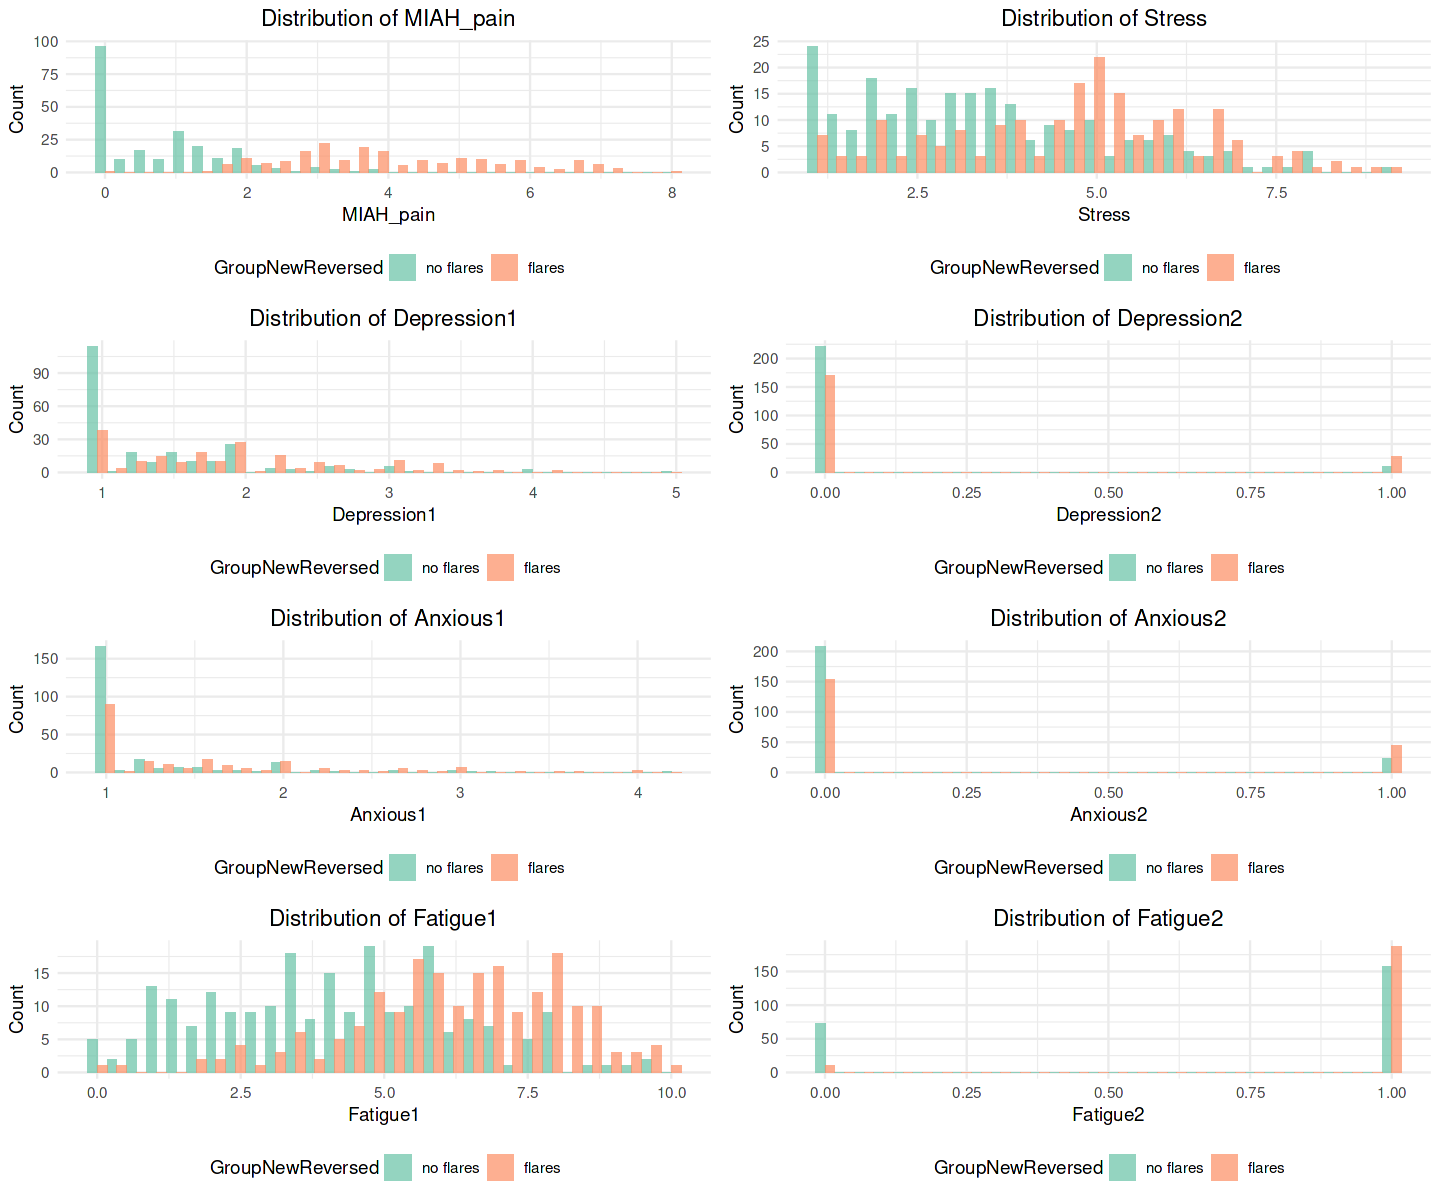

In [15]:
# Load required libraries
library(purrr)
library(gridExtra)

# Get list of numeric columns (excluding GroupNewReversed)
numeric_cols <- names(quantitative_data)[sapply(quantitative_data, is.numeric)]
numeric_cols <- numeric_cols[numeric_cols != "GroupNewReversed"]

# Function to create histogram for each variable
create_histogram <- function(data, var) {
  ggplot(data, aes(x = .data[[var]], fill = GroupNewReversed)) +
    geom_histogram(position = "dodge", bins = 30, alpha = 0.7) +
    theme_minimal() +
    labs(title = paste("Distribution of", var),
         x = var,
         y = "Count") +
    theme(legend.position = "bottom",
          plot.title = element_text(hjust = 0.5)) +
    scale_fill_brewer(palette = "Set2")
}

# Create list of plots
plots <- map(numeric_cols, ~create_histogram(quantitative_data, .x))

# Arrange plots in a grid
# Calculate number of rows and columns for grid
n_plots <- length(plots)
n_cols <- min(2, n_plots)
n_rows <- ceiling(n_plots / n_cols)

# Set default figure size
options(repr.plot.width=12, repr.plot.height=10)
# Create grid of plots
grid.arrange(grobs = plots, ncol = n_cols, nrow = n_rows)





## II.2 lifestyle Statistics

In [16]:
# Select only qualitative variables (character or factor types)
qualitative_data <- joined_data[c(2,34:36)] %>% 
  select(where(is.factor))

# Compute cross frequency and percentage for each explanatory factor
cross_freq <- qualitative_data %>%
  pivot_longer(-GroupNewReversed, names_to = "Variable", values_to = "Value") %>%
  group_by(Variable, GroupNewReversed, Value) %>%
  summarise(Frequency = n(), .groups = "drop") %>%
  mutate(Percentage = Frequency / sum(Frequency) * 100)  # Calculate percentage


# Define a mapping of variable names to labels
label_mapping <- c(
    LifeEvents_incase = "Life Events",
    Smoking_final  =   "Current smoking at baseline",
    PhysicalExercise = "Physical Exercise"
)

# Automatically gather unique categories from the data
apa_table <- cross_freq %>%
  select(Variable, Value,GroupNewReversed,  Frequency, Percentage) %>%
  rename(Category = Value) %>%
  arrange(Variable, Category, GroupNewReversed) %>%
  # Replace variable names with labels using the mapping
  mutate(Variable = recode(Variable, !!!label_mapping),
         GroupNewReversed = recode(GroupNewReversed, `No` = "No Flare", `Yes` = "Flare")) 


# Print the APA-style table
print(kable(apa_table, format = "markdown", align = "c"))



|          Variable           |  Category   | GroupNewReversed | Frequency | Percentage |
|:---------------------------:|:-----------:|:----------------:|:---------:|:----------:|
|      LifeEvents_inCase      |     No      |    no flares     |    102    |  7.925408  |
|      LifeEvents_inCase      |     No      |      flares      |    48     |  3.729604  |
|      LifeEvents_inCase      |     Yes     |    no flares     |    129    | 10.023310  |
|      LifeEvents_inCase      |     Yes     |      flares      |    150    | 11.655012  |
|      Physical Exercise      |    none     |    no flares     |    166    | 12.898213  |
|      Physical Exercise      |    none     |      flares      |    135    | 10.489510  |
|      Physical Exercise      | very active |    no flares     |    65     |  5.050505  |
|      Physical Exercise      | very active |      flares      |    63     |  4.895105  |
| Current smoking at baseline |    Never    |    no flares     |    98     |  7.614608  |
| Curren

## II.2 Medicament Statistics

In [17]:
# Select only qualitative variables (character or factor types)
qualitative_data <- joined_data[c(2, 37:46)] %>% 
  select(where(is.factor))

# Compute cross frequency and percentage for each explanatory factor
cross_freq <- qualitative_data %>%
  pivot_longer(-GroupNewReversed, names_to = "Variable", values_to = "Value") %>%
  group_by(Variable, GroupNewReversed, Value) %>%
  summarise(Frequency = n(), .groups = "drop") %>%
  mutate(Percentage = Frequency / sum(Frequency) * 100)  # Calculate percentage


# Automatically gather unique categories from the data
apa_table <- cross_freq %>%
  select(Variable, Value,GroupNewReversed,  Frequency, Percentage) %>%
  rename(Category = Value) %>%
  arrange(Variable, Category, GroupNewReversed)


# Print the APA-style table
print(kable(apa_table, format = "markdown", align = "c"))



|    Variable    | Category | GroupNewReversed | Frequency | Percentage |
|:--------------:|:--------:|:----------------:|:---------:|:----------:|
|   Adalimumab   |    No    |    no flares     |    168    | 3.9160839  |
|   Adalimumab   |    No    |      flares      |    144    | 3.3566434  |
|   Adalimumab   |   Yes    |    no flares     |    58     | 1.3519814  |
|   Adalimumab   |   Yes    |      flares      |    40     | 0.9324009  |
|   Adalimumab   |    NA    |    no flares     |     5     | 0.1165501  |
|   Adalimumab   |    NA    |      flares      |    14     | 0.3263403  |
|   Budesonide   |    No    |    no flares     |    200    | 4.6620047  |
|   Budesonide   |    No    |      flares      |    167    | 3.8927739  |
|   Budesonide   |   Yes    |    no flares     |    27     | 0.6293706  |
|   Budesonide   |   Yes    |      flares      |    26     | 0.6060606  |
|   Budesonide   |    NA    |    no flares     |     4     | 0.0932401  |
|   Budesonide   |    NA    |      f

# III. G-model

The dependent variable (DV) is `GroupNewReversed` and four groups of independent variables identified by their indices: `Baseline` ( from 3 to 25) , `psychosocial` (from 26 to 33),  `lifestyle` (from 34 to 36), `Medicament`  (from 37 to 46)

## III.1 Fit the Group Lasso Models
There are SIX models:

## Model 1: BaseLine model 

In [18]:
# Set dataset parameters
#=========================


## 1. Create data matrix for independent variables 
### one-hotmatrix
model_matrix <- model.matrix(~ . , data = joined_data[c(-1)])
#Display all column names
#column_names <- colnames(model_matrix)
#print(column_names)


## 2. Dependent variable
# ---------------------------
y <- as.numeric(model_matrix[,2])  # Convert y from factor to numeric
y <- ifelse(y == 1, -1, 1) # Convert y from {1, 2} to {-1, 1}

In [19]:
model_matrix <- as.data.frame(model_matrix) %>%
    select(-ends_with("NA")) %>%
    as.matrix()
column_names <- colnames(model_matrix)
print(column_names)

 [1] "(Intercept)"                              
 [2] "GroupNewReversedflares"                   
 [3] "GenderMale"                               
 [4] "AgeAtCohortEntry"                         
 [5] "DiseaseEntityUC"                          
 [6] "AgeatDiag"                                
 [7] "DiseaseDurationAtCohortEntry"             
 [8] "DiseaseDurationCategory1"                 
 [9] "Montreal_A_diag16-40"                     
[10] "Montreal_A_diag>40"                       
[11] "Montreal_L_diag_finalcolonic"             
[12] "Montreal_L_diag_finalileocolonic"         
[13] "Montreal_B_diag_finalstricturing"         
[14] "Montreal_B_diag_finalpenetrating"         
[15] "Montreal_P_diag_finalYes"                 
[16] "Montreal_P_ever_manualfinalYes"           
[17] "Montreal_U_diag_finalYes"                 
[18] "Montreal_U_ever_finalYes"                 
[19] "Montreal_E_diag_Finalleft-sided colitis"  
[20] "Montreal_E_diag_Finalextensive/pancolitis"
[21] "Montreal_E_eve

remove [34] "MIAH_pain" 

In [20]:
### Create data matrix for independent variables based on the final numeric matrix
x1 <- as.matrix(model_matrix[, c(3:33)])#, 34:41, 42:45, 46:55)])  # Adjust column indices as needed

## Independent variables grouped by the specified indices
# ---------------------------
group_indices1 <- c(rep(1,31)) #, rep(2, 8), rep(3, 4)) , rep(4, 10))  # Group assignments

In [21]:
# # Perform cross-validation to find the best lambda
#=========================
model1 <- cv.gglasso(x = x1, y = y, group = group_indices1, loss = "logit", nfolds = 3)

# Extract the best lambda value
best_lambda <- model1$lambda.min  # or cv_model$lambda.1se for a more regularized model

# Print the best lambda
cat("Best Lambda:", best_lambda, "\n")


Best Lambda: 0.006611166 


## Model 2: BaseLine + psychosocial model 

In [22]:
## 1. Create data matrix for independent variables 
x2 <- as.matrix(model_matrix[,  c(3:33, 35:41)])#, 42:45, 46:55)])  # Adjust column indices as needed

## 3. Independent variables grouped by the specified indices
# ---------------------------
group_indices2 <- c(rep(1,31), rep(2, 7))#, rep(3, 4)) , rep(4, 10))  # Group assignments

In [23]:
# # Perform cross-validation to find the best lambda
#=========================
model2 <- cv.gglasso(x = x2, y = y, group = group_indices2, loss = "logit", nfolds = 3)

# Extract the best lambda value
best_lambda2 <- model2$lambda.min  

# Print the best lambda
cat("Best Lambda:", best_lambda2, "\n")

Best Lambda: 0.09971563 


##  Model 3: BaseLine + psychosocial + lifestyle model 

In [24]:
## 1. Create data matrix for independent variablse 
x3 <- as.matrix(model_matrix[,  c(3:33, 35:41, 42:45)])#, 46:55)]) # Adjust column indices as needed

## 3. Independent variables grouped by the specified indices
# ---------------------------
group_indices3 <- c(rep(1,31), rep(2, 7), rep(3, 4))# , rep(4, 10))  # Group assignments

In [25]:
# # Perform cross-validation to find the best lambda
#=========================
model3 <- cv.gglasso(x = x3, y = y, group = group_indices3, loss = "logit", nfolds = 3)

# Extract the best lambda value
best_lambda3 <- model3$lambda.min  # or cv_model$lambda.1se for a more regularized model

# Print the best lambda
cat("Best Lambda:", best_lambda3, "\n")


Best Lambda: 0.004628389 


## New Model 1: Model with only Psychosocial factors 
 

In [26]:
## 1. Create data matrix for independent variables 
x5 <- as.matrix(model_matrix[, c(35:41)])  # Adjust column indices as needed

## 3. Independent variables grouped by the specified indices
# ---------------------------
group_indices5 <- c(rep(1, 7)) # Group assignments

In [27]:
# # Perform cross-validation to find the best lambda
#=========================
model5 <- cv.gglasso(x = x5, y = y, group = group_indices5, loss = "logit", nfolds = 3)
 
# Extract the best lambda value
best_lambda5 <- model5$lambda.min  

# Print the best lambda
cat("Best Lambda:", best_lambda5, "\n")

Best Lambda: 0.001742559 


## New Model 2: Model with only lifestyle factors

In [29]:
# # Perform cross-validation to find the best lambda
#=========================
model6 <- cv.gglasso(x = x6, y = y, group = group_indices6, loss = "logit", nfolds = 3)

# Extract the best lambda value
best_lambda6 <- model6$lambda.min  # or cv_model$lambda.1se for a more regularized model

# Print the best lambda
cat("Best Lambda:", best_lambda6, "\n")



Best Lambda: 0.01351228 


In [30]:
# Fit the Group Lasso model using the optimal lambda
optimal_model1 <- gglasso(x = x1, y = y, group = group_indices1, loss = "logit", lambda = best_lambda)
optimal_model2 <- gglasso(x = x2, y = y, group = group_indices2, loss = "logit", lambda = best_lambda2)
optimal_model3 <- gglasso(x = x3, y = y, group = group_indices3, loss = "logit", lambda = best_lambda3)

optimal_model5 <- gglasso(x = x5, y = y, group = group_indices5, loss = "logit", lambda = best_lambda5)
optimal_model6 <- gglasso(x = x6, y = y, group = group_indices6, loss = "logit", lambda = best_lambda6)

## III.2 Performance Metrics

We are going to summarize the Group Lasso models, extract results, compute performance metrics (accuracy, AUC, and AIC), and visualize regression coefficients:



In [31]:
# 1. Summary of the Model
#--------------------------
# Extract coefficients for each model
coef_model1 <- coef(optimal_model1)
coef_model2 <- coef(optimal_model2)
coef_model3 <- coef(optimal_model3)


coef_model5 <- coef(optimal_model5)
coef_model6 <- coef(optimal_model6)

# Display summaries (coefficients) for each model
print(paste0('Coefficients for model 1'))
print(coef_model1)

print(paste0('Coefficients for model 2'))
print(coef_model2)

print(paste0('Coefficients for model 3'))
print(coef_model3)

print(paste0('Coefficients for model 5'))
print(coef_model5)

print(paste0('Coefficients for model 6'))
print(coef_model6)

[1] "Coefficients for model 1"
                                                    s0
(Intercept)                                0.765655780
GenderMale                                -0.386956333
AgeAtCohortEntry                           0.011157314
DiseaseEntityUC                            0.102293164
AgeatDiag                                 -0.002999729
DiseaseDurationAtCohortEntry               0.013956447
DiseaseDurationCategory1                   0.213376165
Montreal_A_diag16-40                      -0.004783126
Montreal_A_diag>40                         0.035363424
Montreal_L_diag_finalcolonic               0.111476672
Montreal_L_diag_finalileocolonic          -0.074706388
Montreal_B_diag_finalstricturing          -0.019801451
Montreal_B_diag_finalpenetrating          -0.056161930
Montreal_P_diag_finalYes                  -0.055907046
Montreal_P_ever_manualfinalYes             0.045265772
Montreal_U_diag_finalYes                   0.014698234
Montreal_U_ever_finalYes          

###  2. Compute Performance Metrics

For each model, compute accuracy, and AUC

In [38]:
# Function to calculate metrics
calculate_metrics <- function(actual, predicted) {
    confusion_matrix <- table(factor(actual), factor(predicted))
    
    sensitivity <- confusion_matrix[2,2] / sum(confusion_matrix[2,])   # True Positives / (True Positives + False Negatives)
    specificity <- confusion_matrix[1,1] / sum(confusion_matrix[1,])   # True Negatives / (True Negatives + False Positives)
    ppv <- confusion_matrix[2,2] / sum(confusion_matrix[,2])            # True Positives / (True Positives + False Positives)
    npv <- confusion_matrix[1,1] / sum(confusion_matrix[,1])            # True Negatives / (True Negatives + False Negatives)
    
    return(c(Sensitivity = sensitivity,
             Specificity = specificity,
             PPV = ppv,
             NPV = npv))
}

In [60]:
# 2. Compute Performance Metrics
#--------------------------

# Function to compute performance metrics
compute_metrics <- function(model, x) {
    predicted_probs <- plogis(predict(model, newx = x, type = "link")) # Use link for probabilities
    y_binary <- factor(ifelse(y == -1, 0, 1))
    
    # Calculate ROC curve
    suppressMessages(suppressWarnings(
        roc_curve <- roc(y_binary, as.vector(predicted_probs))
    ))
    
    # Find optimal threshold
    optimal_threshold <- coords(roc_curve, "best", ret = "threshold")
   
    # Convert probabilities to predicted classes using optimal threshold
    predicted_classes <- ifelse(predicted_probs > optimal_threshold$threshold, 1, 0)
    
    # Calculate accuracy
    accuracy <- mean(predicted_classes == y_binary)
    
    # Calculate AUC
    auc_value <- auc(roc_curve)
    
    # Calculate metrics for each model
    metrics_model <- calculate_metrics(y_binary, predicted_classes)
    
    return(list(
        accuracy = accuracy, 
        auc = auc_value, 
        metrics = metrics_model
    ))
}
# Compute metrics for all models
metrics_model1 <- compute_metrics(model= optimal_model1, x=x1)
metrics_model2 <- compute_metrics(model = optimal_model2, x=x2)
metrics_model3 <- compute_metrics(model = optimal_model3, x=x3)


metrics_model5 <- compute_metrics(model = optimal_model5, x=x5)
metrics_model6 <- compute_metrics(model = optimal_model6, x=x6)

# Print performance metrics
cat("Model 1: BaseLine - Accuracy:", metrics_model1$accuracy, "AUC:", metrics_model1$auc, "\n")
cat("Model 2: BaseLine+Psychosocial - Accuracy:", metrics_model2$accuracy, "AUC:", metrics_model2$auc, "\n")
cat("Model 3: BaseLine+P+Lifestyle - Accuracy:", metrics_model3$accuracy, "AUC:", metrics_model3$auc,  "\n")

cat("Model 5: Psychosocial - Accuracy:", metrics_model5$accuracy, "AUC:", metrics_model5$auc,  "\n")
cat("Model 6: Lifestyle - Accuracy:", metrics_model6$accuracy, "AUC:", metrics_model6$auc, "\n")

Model 1: BaseLine - Accuracy: 0.6573816 AUC: 0.687673 
Model 2: BaseLine+Psychosocial - Accuracy: 0.735376 AUC: 0.7943082 
Model 3: BaseLine+P+Lifestyle - Accuracy: 0.7493036 AUC: 0.8159119 
Model 5: Psychosocial - Accuracy: 0.7437326 AUC: 0.7909119 
Model 6: Lifestyle - Accuracy: 0.5849582 AUC: 0.6068082 


In [61]:
# Create a results table
results_table <- data.frame(
    Model = c("Model 1: BaseLine", 
              "Model 2: BaseLine+Psychosocial", 
              "Model 3: BaseLine+P+Lifestyle", 
              
              "Model 5: Psychosocial", 
              "Model 6: Lifestyle"),
    Sensitivity = c(metrics_model1$metrics[1], metrics_model2$metrics[1],
                    metrics_model3$metrics[1],
                   metrics_model5$metrics[1], metrics_model6$metrics[1]),
    
    Specificity = c(metrics_model1$metrics[2], metrics_model2$metrics[2],
                    metrics_model3$metrics[2], 
                    metrics_model5$metrics[2], metrics_model6$metrics[2]),
    
    PPV = c(metrics_model1$metrics[3], metrics_model2$metrics[3],
            metrics_model3$metrics[3], 
           metrics_model5$metrics[3], metrics_model6$metrics[3]),
    
    NPV = c(metrics_model1$metrics[4], metrics_model2$metrics[4],
            metrics_model3$metrics[4],
            metrics_model5$metrics[4], metrics_model6$metrics[4])
)

# Print the results table
print(results_table)

                           Model Sensitivity Specificity       PPV       NPV
1              Model 1: BaseLine       0.685   0.6226415 0.6954315 0.6111111
2 Model 2: BaseLine+Psychosocial       0.665   0.8238994 0.8260870 0.6616162
3  Model 3: BaseLine+P+Lifestyle       0.700   0.8113208 0.8235294 0.6825397
4          Model 5: Psychosocial       0.720   0.7735849 0.8000000 0.6871508
5             Model 6: Lifestyle       0.415   0.7987421 0.7217391 0.5204918


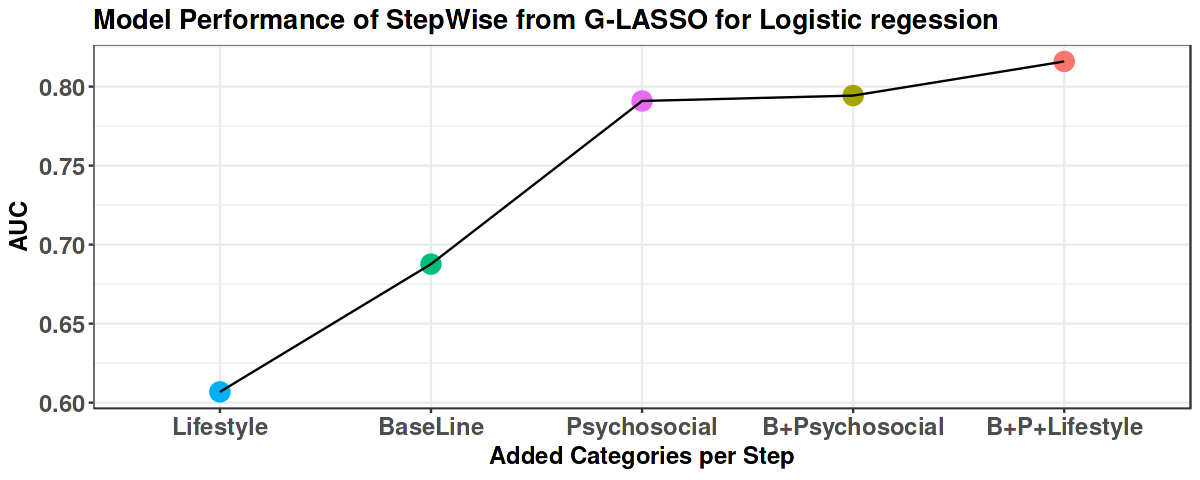

In [62]:
# data frame for models importance
variable_importance <- data.frame(
  Variable = c("BaseLine", "B+Psychosocial", "B+P+Lifestyle", 
               
               "Psychosocial", "Lifestyle"),
  Importance = c(metrics_model1$auc, metrics_model2$auc, 
                 metrics_model3$auc, 
                metrics_model5$auc, metrics_model6$auc)
)
options(repr.plot.width=10, repr.plot.height=4)
# Create Figure : Variable Importance Plot
ggplot(variable_importance, aes(x = reorder(Variable, Importance), y = Importance)) +
  geom_point(aes(color = Variable), size = 5) +
  geom_line(group = 10) +
  labs(title = "Model Performance of StepWise from G-LASSO for Logistic regession",
       x = "Added Categories per Step",
       y = "AUC")+
  theme_bw() + # Apply a clean theme
  theme(
      legend.position="none",
    plot.title = element_text(size = 16, face = "bold"), # Title size and style
    axis.title.x = element_text(size = 14, face = "bold"), # X-axis label size
    axis.title.y = element_text(size = 14, face = "bold"), # Y-axis label size
    axis.text.x = element_text(size = 14, face = "bold"), # X-axis text size
    axis.text.y = element_text(size = 14, face = "bold") # Y-axis text size
  ) 


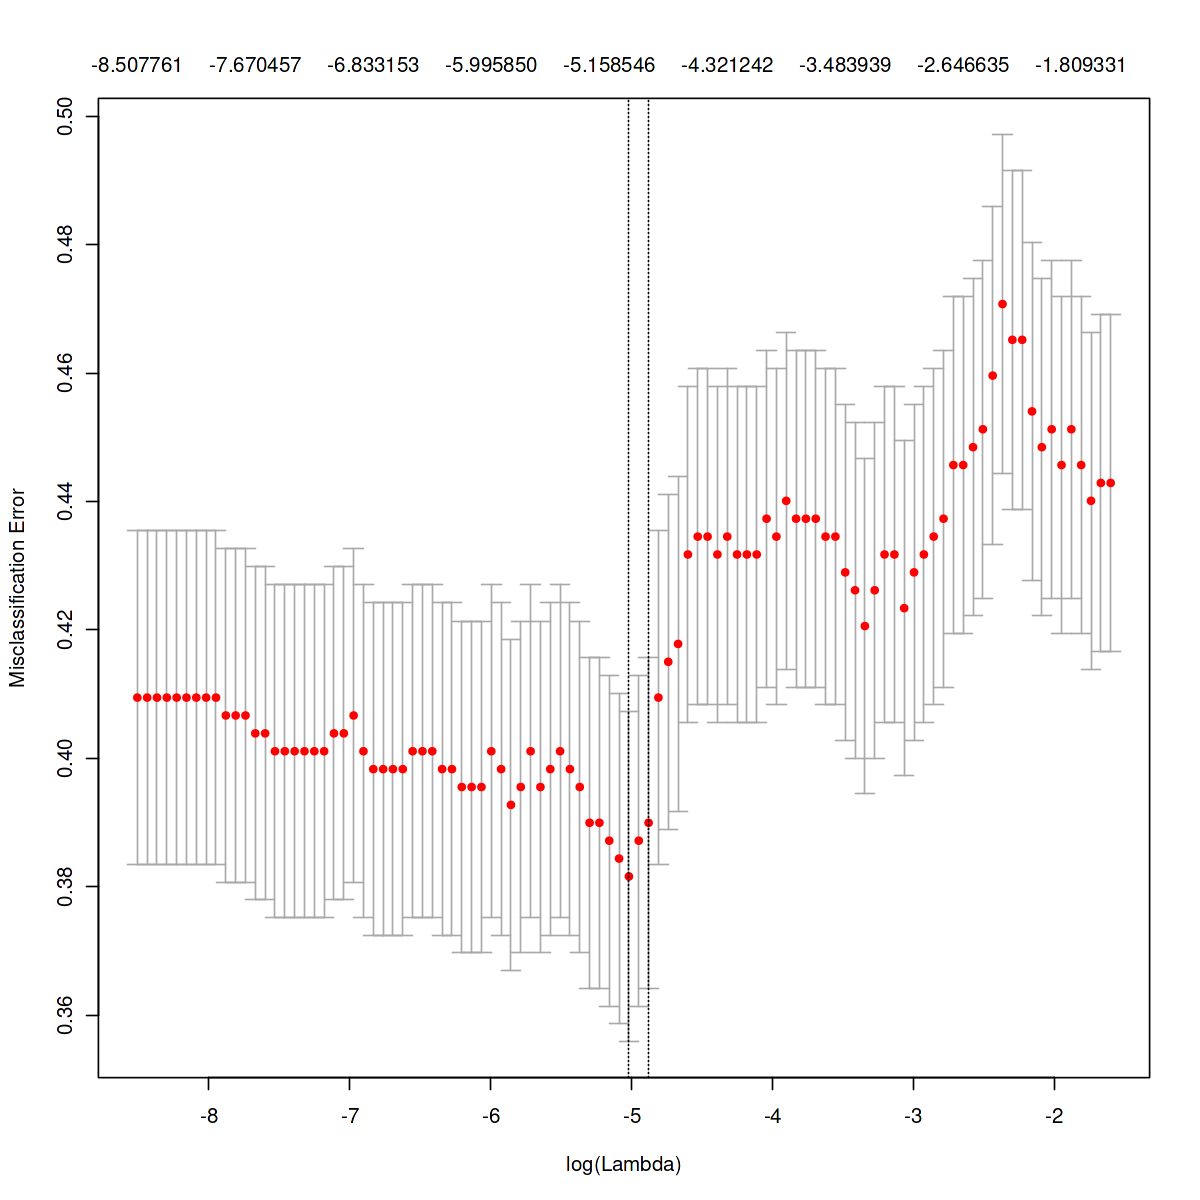

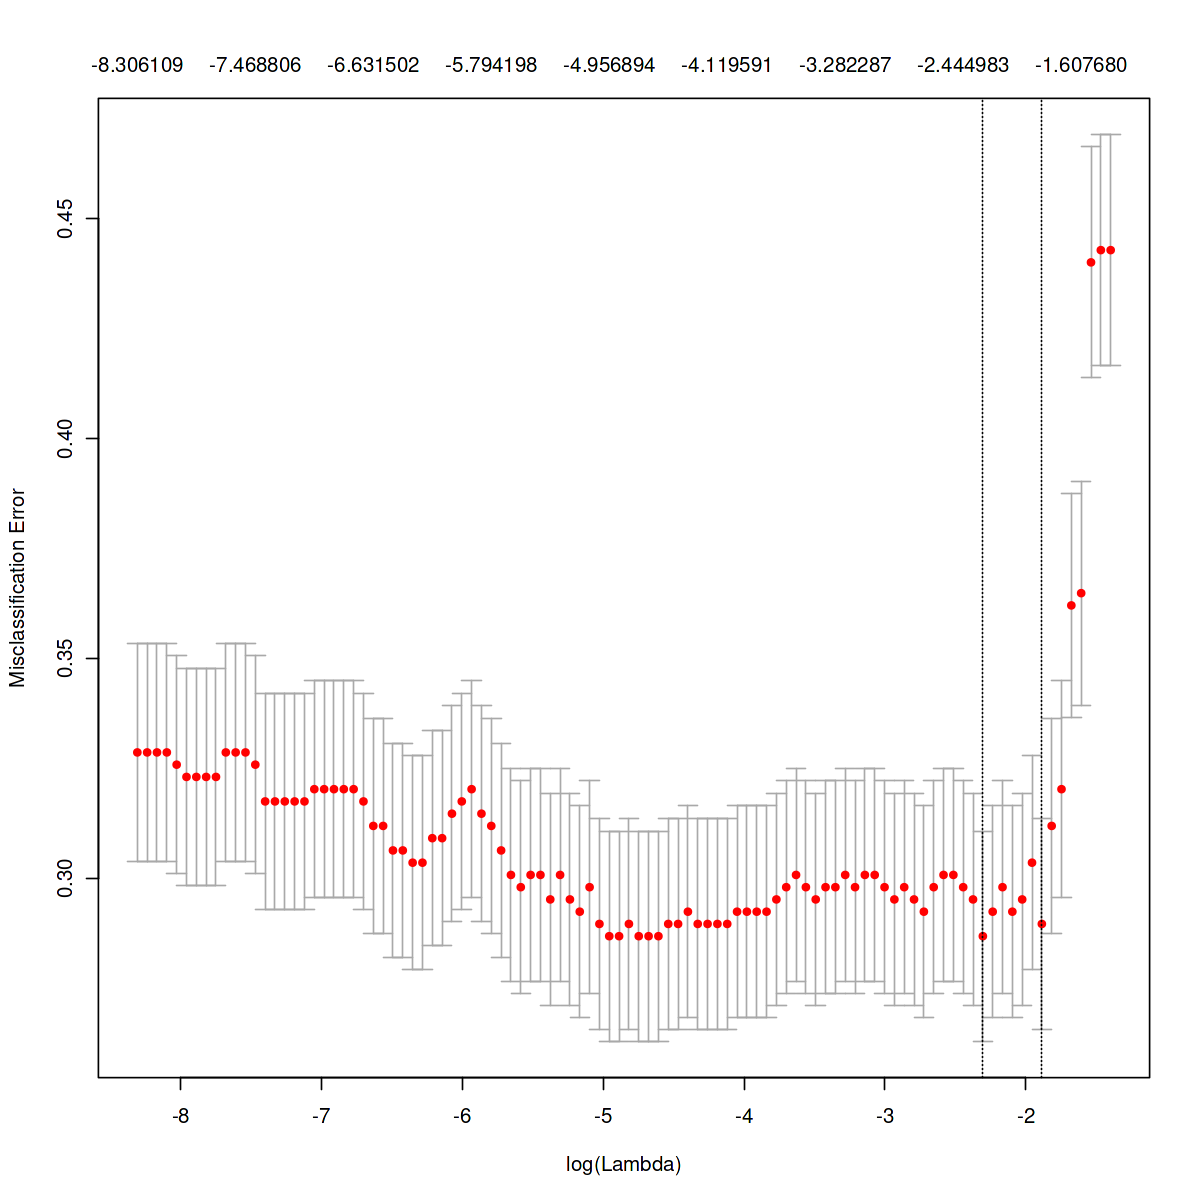

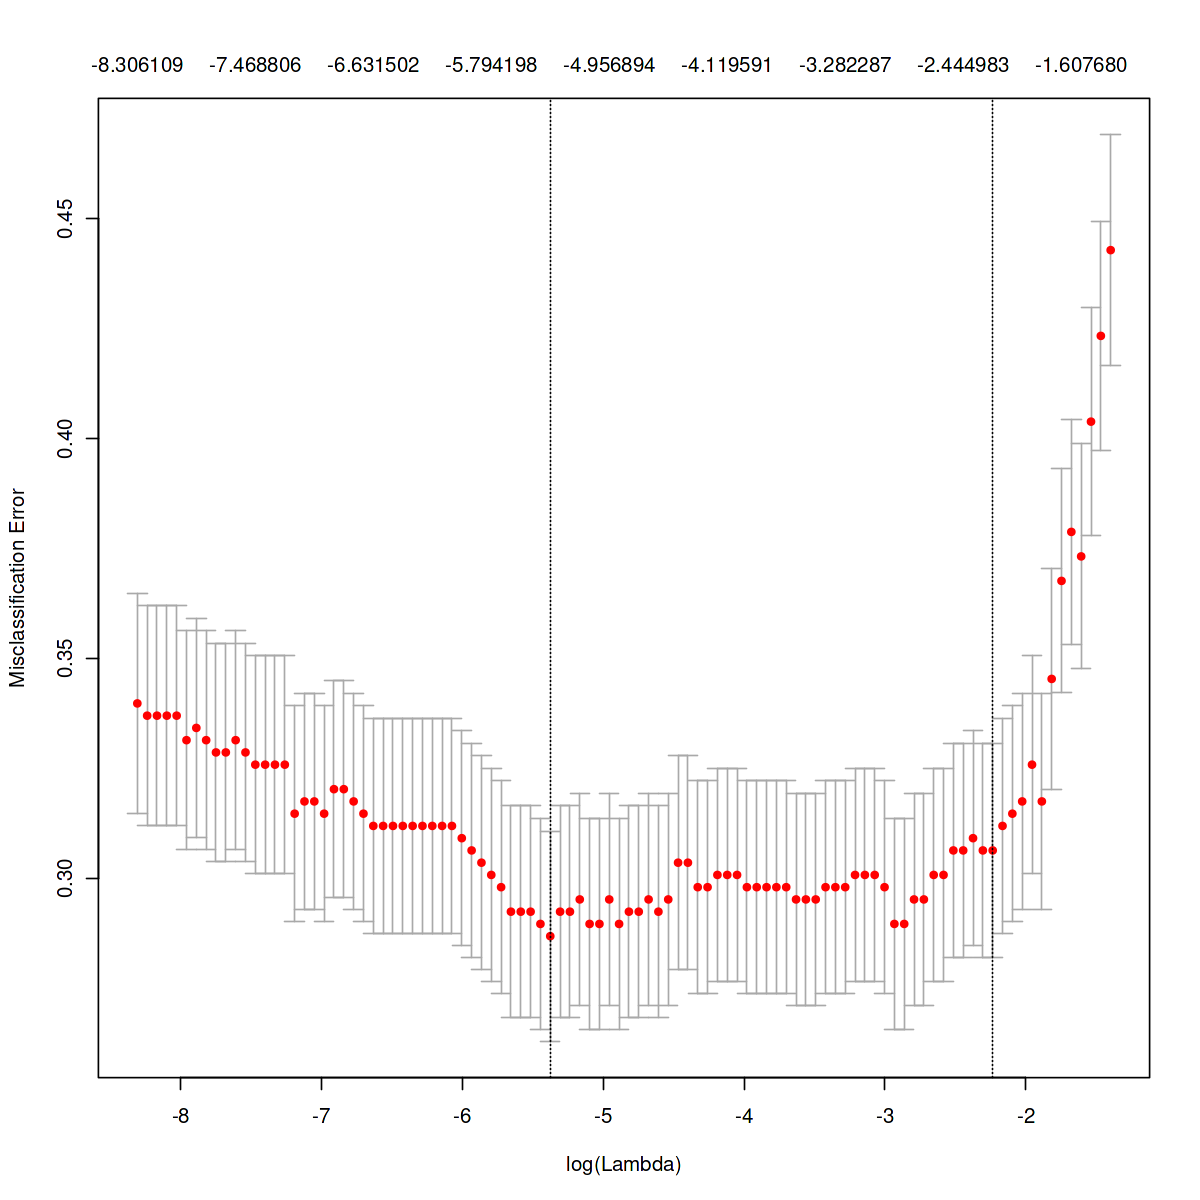

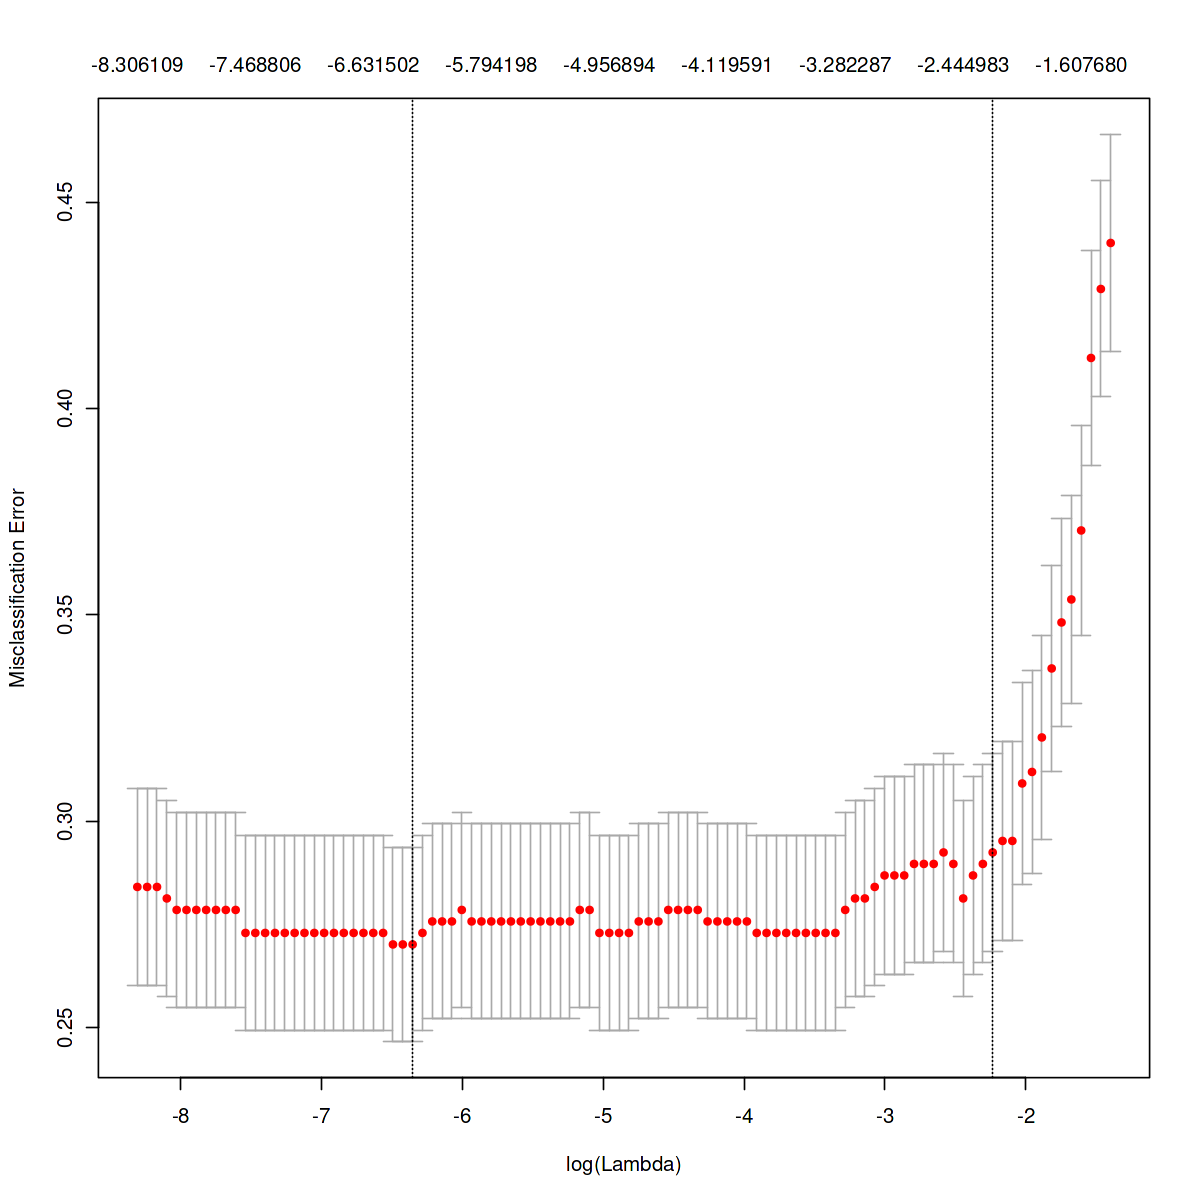

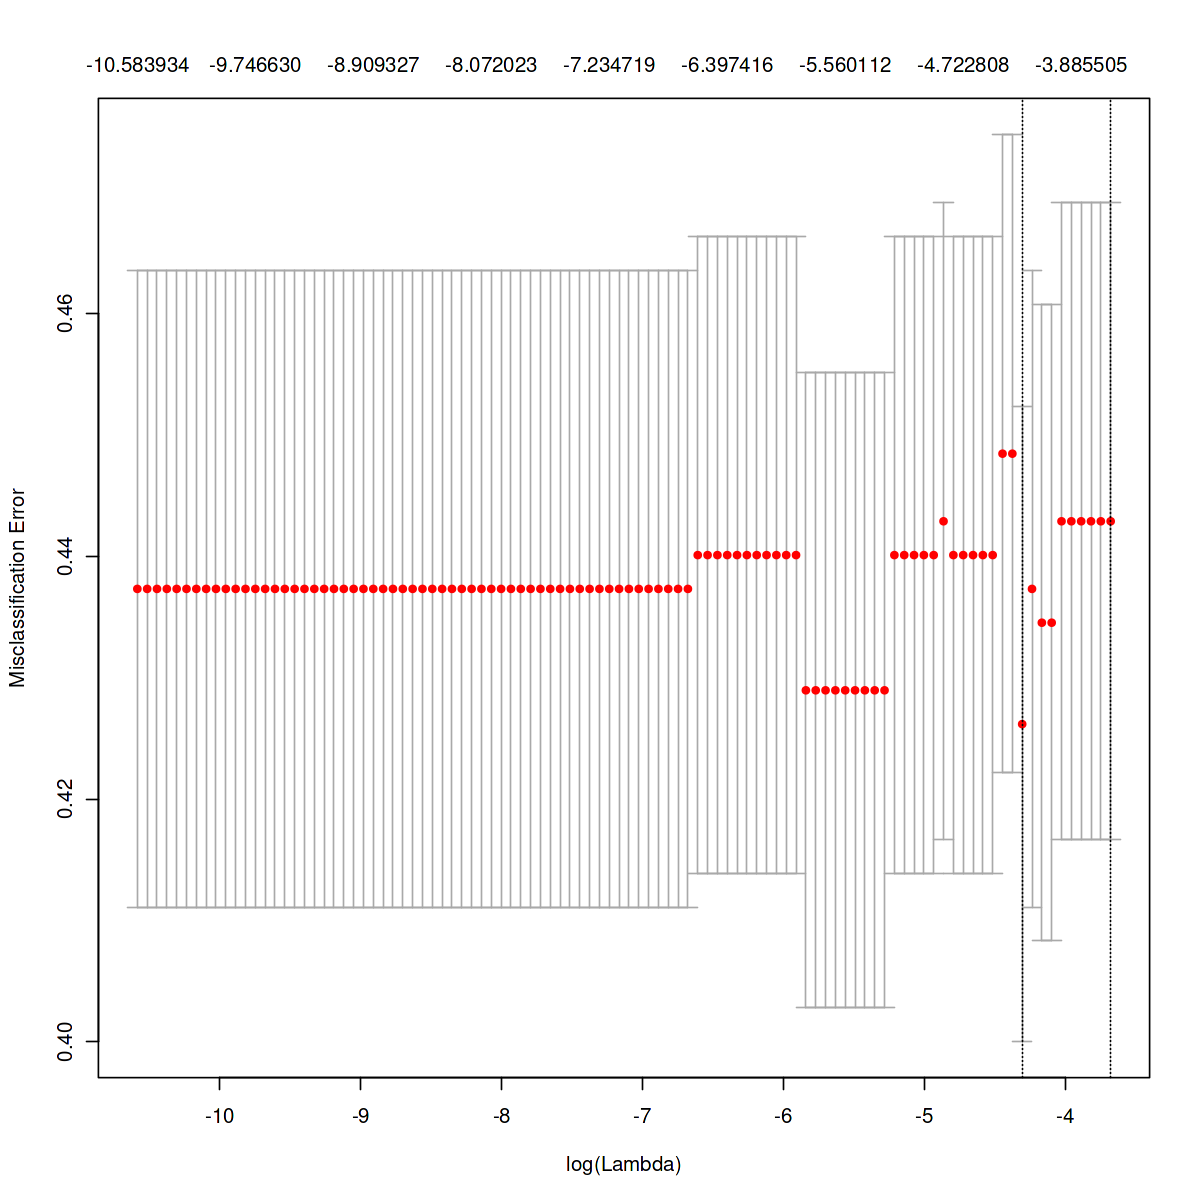

In [63]:
# Set default figure size
options(repr.plot.width=10, repr.plot.height=10)

plot(model1) #  main = "CV:  BaseLine
plot(model2)# , main = "CV:  Psychosocial"
plot(model3) # , main = "CV:  Lifestyle"
# , main = "CV:  Medicament"

plot(model5) # , main = "CV:  Lifestyle"
plot(model6) # , main = "CV:  Medicament"